In [1]:
# Figure S3: peak-assignment window sensitivity. Analysis C's headline number (101
# of 391 spg-7 ATFS-1-dependent genes bound, at a 2kb window with peaks assigned to
# either a gene's own TSS or its operon head's TSS) depends on two analysis choices:
# how wide a window counts as "bound", and whether operon structure is used at all.
# gate_decisions.md already describes, qualitatively, that a 1kb/2kb/5kb sweep is
# what surfaced the tspo-1 false-negative during development - this notebook is the
# first time that sweep is actually run end-to-end and recorded with numbers, rather
# than described from memory of having done it once. Re-derives gene models, operons,
# and peaks the same validated way as analysis_c.ipynb / table_1.ipynb / figure_2.ipynb.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from figure_style import BLUE, ORANGE, GREY, INK, THREEQ_W, panel_label, save

GFF = "data/raw/c_elegans.PRJNA13758.WS285.annotations.gff3.gz"
genes = {}
with gzip.open(GFF, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[1] != "WormBase" or f[2] != "gene":
            continue
        attrs = dict(kv.split("=", 1) for kv in f[8].split(";") if "=" in kv)
        gid_raw = attrs.get("ID", "")
        gid = gid_raw.replace("Gene:", "") if gid_raw.startswith("Gene:") else gid_raw
        if not gid.startswith("WBGene"):
            continue
        genes[gid] = {"chr": f[0], "start": int(f[3]), "end": int(f[4]), "strand": f[6],
                       "seqname": attrs.get("sequence_name", "")}
for g in genes.values():
    g["tss"] = g["start"] if g["strand"] == "+" else g["end"]

operons = {}
with gzip.open(GFF, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[1] != "operon" or f[2] != "operon":
            continue
        attrs = dict(kv.split("=", 1) for kv in f[8].split(";") if "=" in kv)
        name = attrs.get("Name")
        members = attrs.get("genes", "").split(",") if attrs.get("genes") else []
        if name and members:
            operons[name] = members
gene_to_head = {m: members[0] for members in operons.values() for m in members[1:]}
for gid, g in genes.items():
    g["operon_role"] = "downstream" if gid in gene_to_head else "head_or_independent"
    if g["operon_role"] == "downstream" and gene_to_head[gid] in genes:
        g["head_tss"] = genes[gene_to_head[gid]]["tss"]
        g["head_chr"] = genes[gene_to_head[gid]]["chr"]
    else:
        g["head_tss"] = None

print(f"Gene models: {len(genes):,}; operons: {len(operons):,}; "
      f"downstream members: {len(gene_to_head):,}")

Gene models: 47,649; operons: 1,385; downstream members: 2,107


In [2]:
# Peaks and the primary, condition-matched gene set (Nargund 2012 Table S3,
# 391 genes) - same loading and row-count fix as analysis_c.ipynb.
peaks = pd.read_csv("data/liftover/peaks_ce11.bed", sep="\t", header=None,
                     names=["chr", "start", "end", "name"])
peaks["chr"] = peaks["chr"].str.replace("^chr", "", regex=True)
if len(peaks) != 1005:
    raise RuntimeError(f"Expected 1005 peaks, got {len(peaks)}.")

table_s3 = pd.read_excel("data/raw/nargund2012_TableS3_spg7_ATFS1dependent.xlsx",
                          sheet_name="Sheet1", header=None)
table_s3.columns = ["seqname", "symbol", "function", "wt_fold", "atfs1_fold",
                     "fold_diff", "blank", "pct_less", "na"]
table_s3["wt_fold_numeric"] = pd.to_numeric(table_s3["wt_fold"], errors="coerce")
table_s3 = table_s3[table_s3["wt_fold_numeric"].notna()].copy()
table_s3["seqname"] = table_s3["seqname"].astype(str).str.strip()

seq_to_gid = {g["seqname"].lower(): gid for gid, g in genes.items() if g.get("seqname")}
table_s3["gid"] = table_s3["seqname"].str.lower().map(seq_to_gid)
unresolved = int(table_s3["gid"].isna().sum())
# Rows that don't resolve stay in the table (gid=NaN) rather than being dropped -
# analysis_c.ipynb's denominator is all 391 real rows, not just the resolved ones,
# since an unresolved gene is correctly counted as "not bound" rather than excluded.
# Dropping them here would shrink the denominator and change the percentage even
# though the reported number is a fraction of 391, not of 381.
if len(table_s3) != 391 or unresolved != 10:
    raise RuntimeError(f"Expected 391 rows with 10 unresolved, got {len(table_s3)} rows, {unresolved} unresolved.")
print(f"Table S3: {len(table_s3)} genes ({unresolved} unresolved to a current gene ID, kept as not-bound)")

Table S3: 391 genes (10 unresolved to a current gene ID, kept as not-bound)


/opt/homebrew/Caskroom/miniforge/base/envs/atfs1/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
# The sweep: for each window size, and with/without operon logic, what fraction of
# the 391-gene set is called bound? Own TSS is always checked; operon logic adds the
# head TSS as a second candidate for downstream members only.
#
# A first version of this rebuilt per-chromosome gene lists and scanned every gene
# against every peak (the same approach analysis_c.ipynb uses for its one reported
# number) - fine for one run, far too slow for a 6-window x 2-rule sweep (12 runs).
# Sorted-array binary search gives the identical answer for the identical rule,
# just fast enough to sweep: for each chromosome, TSS values are sorted once, and
# each peak's window is resolved with two searchsorted calls instead of a scan over
# every gene on that chromosome.
own_by_chr, head_by_chr = {}, {}
for gid, g in genes.items():
    own_by_chr.setdefault(g["chr"], []).append((g["tss"], gid))
    if g["operon_role"] == "downstream" and g["head_tss"] is not None:
        head_by_chr.setdefault(g["head_chr"], []).append((g["head_tss"], gid))

def _sorted_arrays(by_chr):
    out = {}
    for chrom, pairs in by_chr.items():
        pairs = sorted(pairs)
        out[chrom] = (np.array([p[0] for p in pairs]), [p[1] for p in pairs])
    return out

own_sorted = _sorted_arrays(own_by_chr)
head_sorted = _sorted_arrays(head_by_chr)
peaks_by_chr = {c: g[["start", "end"]].to_numpy() for c, g in peaks.groupby("chr")}

def genes_in_range(sorted_arrays, chrom, lo, hi):
    if chrom not in sorted_arrays:
        return []
    tss_vals, gids = sorted_arrays[chrom]
    i0 = np.searchsorted(tss_vals, lo, side="left")
    i1 = np.searchsorted(tss_vals, hi, side="right")
    return gids[i0:i1]

def bound_fraction(window, use_operon):
    bound = set()
    for chrom, arr in peaks_by_chr.items():
        for start, end in arr:
            lo, hi = start - window, end + window
            bound.update(genes_in_range(own_sorted, chrom, lo, hi))
            if use_operon:
                bound.update(genes_in_range(head_sorted, chrom, lo, hi))
    n_bound = int(table_s3["gid"].isin(bound).sum())
    return n_bound, 100 * n_bound / len(table_s3)

WINDOWS = [500, 1000, 2000, 3000, 5000, 10000]
rows = []
for w in WINDOWS:
    for use_operon in (False, True):
        n, pct = bound_fraction(w, use_operon)
        rows.append({"window": w, "operon_logic": use_operon, "n_bound": n, "pct": pct})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

headline = sweep[(sweep["window"] == 2000) & (sweep["operon_logic"])].iloc[0]
if int(headline["n_bound"]) != 101:
    raise RuntimeError(f"Headline number changed: got {int(headline['n_bound'])} of 391 at 2kb+operon, expected 101.")
print(f"\nValidated: the reported headline (101 of 391, 25.8%) reproduces exactly "
      f"at the reported window (2kb) and rule (operon logic on).")

# tspo-1 is not itself in this 391-gene set (it comes from a different experiment),
# but the mechanism the reconciliation note describes - operon logic recovering a
# gene right at the boundary of the window - should be visible in this sweep as a
# gap between the with- and without-operon-logic lines that narrows as the window
# widens past where the head-TSS distance would have mattered.
gap_2kb = sweep[(sweep.window == 2000) & sweep.operon_logic]["n_bound"].iloc[0] - \
          sweep[(sweep.window == 2000) & ~sweep.operon_logic]["n_bound"].iloc[0]
print(f"Genes recovered by operon logic specifically at 2kb: {gap_2kb}")

 window  operon_logic  n_bound   pct
    500         False       75 19.18
    500          True       84 21.48
   1000         False       80 20.46
   1000          True       85 21.74
   2000         False       95 24.30
   2000          True      101 25.83
   3000         False       99 25.32
   3000          True      103 26.34
   5000         False      121 30.95
   5000          True      122 31.20
  10000         False      140 35.81
  10000          True      141 36.06

Validated: the reported headline (101 of 391, 25.8%) reproduces exactly at the reported window (2kb) and rule (operon logic on).
Genes recovered by operon logic specifically at 2kb: 6


Saved figures/figureS3_window_sensitivity.{pdf,svg,png}


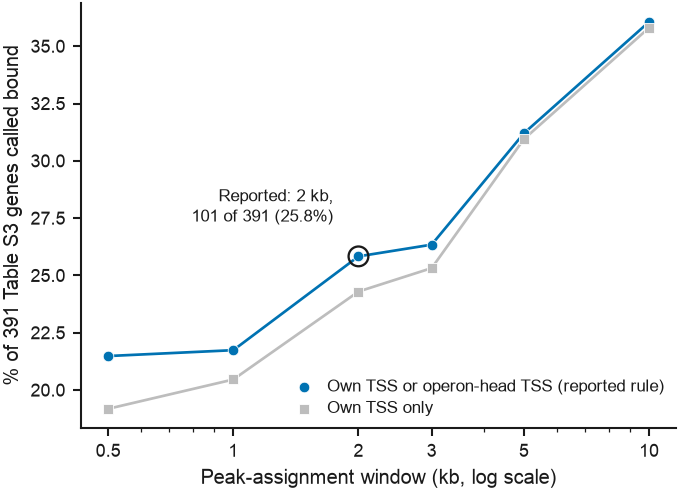

In [4]:
# Draw: % bound vs. window size, with/without operon logic, headline point marked.
fig, ax = plt.subplots(figsize=(THREEQ_W, THREEQ_W * 0.72))
for use_operon, color, marker, label in [
    (True, BLUE, "o", "Own TSS or operon-head TSS (reported rule)"),
    (False, GREY, "s", "Own TSS only"),
]:
    sub = sweep[sweep["operon_logic"] == use_operon].sort_values("window")
    ax.plot(sub["window"] / 1000, sub["pct"], "-", color=color, lw=1.3, zorder=2)
    ax.scatter(sub["window"] / 1000, sub["pct"], s=26, color=color, marker=marker,
               label=label, zorder=3, edgecolors="white", linewidths=0.4)

ax.scatter([2], [headline["pct"]], s=90, facecolors="none", edgecolors=INK,
           linewidths=1.1, zorder=4)
ax.annotate(f"Reported: 2 kb,\n{int(headline['n_bound'])} of 391 ({headline['pct']:.1f}%)",
            (2, headline["pct"]), textcoords="offset points", xytext=(-12, 14),
            ha="right", va="bottom", fontsize=8, color=INK, linespacing=1.3)

ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 3, 5, 10])
ax.set_xticklabels(["0.5", "1", "2", "3", "5", "10"])
ax.set_xlabel("Peak-assignment window (kb, log scale)")
ax.set_ylabel("% of 391 Table S3 genes called bound")
ax.legend(loc="lower right", frameon=False, fontsize=8, handletextpad=0.4)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

save(fig, "figureS3_window_sensitivity")
plt.show()